### Libs import

In [1]:
import os
import math
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

def set_seed(seed: int = 42) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [ ]:
# Параметры
MAX_TICKERS = 60                 
WINDOW_SIZE = 100               
TEST_LEN = 600                  
VAL_LEN = 600                    
BATCH_SIZE = 256

### Dataloading

In [ ]:
full_data = pd.read_csv('D:/ML finance/MLP/data_t.csv', index_col='openTime')

RET_COLS = [col for col in full_data if '_ret' in col]
LEARNING_COLS = [col for col in full_data if '_ret' not in col]
n_features = len(LEARNING_COLS)
n_assets = len(RET_COLS)

print(f"Features: {n_features}")
print(f"Returns: {n_assets}")
print(f"Data shape: {full_data.shape}")

Features: 792
Returns: 99
Data shape: (4343, 891)


## 2) Генерация окон (X) и таргета (y)

- `X[t]` = окно длины `WINDOW_SIZE` из **признаков** (`feature_cols`)  
- `y[t]` = вектор **следующих доходностей** по активам (`ret_cols`)  

Важно: для корректного turnover-пенальти ниже мы оставляем `shuffle=False` и разделяем данные **по времени**.


In [ ]:
from sklearn.preprocessing import StandardScaler

def make_windows(df: pd.DataFrame, feature_cols: list[str], ret_cols: list[str], window_size: int):
    X_list, y_list, idx_list = [], [], []
    values_X = df[feature_cols].values.astype(np.float32)
    values_y = df[ret_cols].values.astype(np.float32)

    for t in range(window_size, len(df)):
        X_list.append(values_X[t-window_size:t, :])
        y_list.append(values_y[t, :])         
        idx_list.append(df.index[t])

    X = np.stack(X_list)  # (n_samples, window, n_features)
    y = np.stack(y_list)  
    idx = pd.Index(idx_list)
    return X, y, idx

X, y, idx = make_windows(full_data, LEARNING_COLS, RET_COLS, WINDOW_SIZE)
print("X:", X.shape, "y:", y.shape)

n = X.shape[0]
test_len = min(TEST_LEN, n//5)
val_len = min(VAL_LEN, n//5)

train_end = n - (val_len + test_len)
val_end = n - test_len

X_train, y_train, idx_train = X[:train_end], y[:train_end], idx[:train_end]
X_val, y_val, idx_val = X[train_end:val_end], y[train_end:val_end], idx[train_end:val_end]
X_test, y_test, idx_test = X[val_end:], y[val_end:], idx[val_end:]

print(f"train: {X_train.shape, y_train.shape}, ({idx_train[0]} to {idx_train[-1]})")
print(f"val:  {X_val.shape, y_val.shape}, ({idx_val[0]} to {idx_val[-1]})")
print(f"test:  {X_test.shape, y_test.shape}, ({idx_test[0]} to {idx_test[-1]})")


X: (4243, 100, 792) y: (4243, 99)
train: ((3043, 100, 792), (3043, 99)), (2021-09-09 16:00:00+00:00 to 2023-01-29 16:00:00+00:00)
val:  ((600, 100, 792), (600, 99)), (2023-01-29 20:00:00+00:00 to 2023-05-09 16:00:00+00:00)
test:  ((600, 100, 792), (600, 99)), (2023-05-09 20:00:00+00:00 to 2023-08-17 16:00:00+00:00)


In [29]:
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, X_train.shape[-1]))

def scale_X(X_):
    Xs = scaler.transform(X_.reshape(-1, X_.shape[-1])).reshape(X_.shape).astype(np.float32)
    return Xs

X_train = scale_X(X_train)
X_val   = scale_X(X_val)
X_test  = scale_X(X_test)

np.isfinite(X_train).all(), np.isfinite(y_train).all()

(np.True_, np.True_)

## 3) DataLoader

In [30]:
class WindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
val_loader   = DataLoader(WindowDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(WindowDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("batch:", xb.shape, yb.shape)

batch: torch.Size([256, 100, 792]) torch.Size([256, 99])


## 4) Модель: LSTM → веса портфеля

Модель принимает окно `WINDOW_SIZE × n_features` и выдаёт `n_assets` скалярных весов.

Мы будем **нормализовать веса внутри loss**, чтобы в них была:
- долларовая нейтральность (sum(w)=0),
- L1-нормировка (sum(|w|)=1).


In [ ]:
class LSTMPortfolio(nn.Module):
    def __init__(self, n_features: int, n_assets: int, hidden: int = 96, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        
        self.hidden = hidden
        self.num_layers = num_layers
        
        self.batch_norm = nn.BatchNorm1d(n_features)
        self.in_dropout = nn.Dropout(dropout)

        self.lstm1 = nn.LSTM(
            n_features, 
            hidden,
            batch_first=True,
            bidirectional=True
        )
        self.lstm2 = nn.LSTM(
            hidden * 2, 
            hidden,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Linear(hidden * 2, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_assets),
        )
        
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.batch_norm(x)
        x = x.permute(0, 2, 1)
        
        x = self.in_dropout(x)
        out1, _ = self.lstm1(x)  
        out2, _ = self.lstm2(out1) 
        h_last = out2[:, -1, :]  
        logits = self.head(h_last)
        
        return logits
    
n_features = X_train.shape[-1]
n_assets = y_train.shape[-1]

model = LSTMPortfolio(n_features=n_features, n_assets=n_assets, hidden=96, num_layers=2, dropout=0.1).to(device)
sum(p.numel() for p in model.parameters()) / 1e6

0.936339

## 5) Пользовательская функция потерь

Мы хотим учить модель **не на MSE по доходностям**, а сразу на то, что важно для стратегии.

### Пример: максимизация Sharpe с штрафом за turnover
1) Получаем веса `w_t` (после нейтрализации + L1-нормировки)  
2) Доходность портфеля `p_t = Σ_i w_{t,i} · r_{t,i}`  
3) Sharpe `S = mean(p) / (std(p)+ε)` → **loss = -S**  
4) Turnover `TO = mean(|w_t - w_{t-1}|)` → добавляем `λ · TO`  

> Для демонстрации достаточно. Если захотите — легко добавить constraints (max_weight, sector-neutral, risk parity и т.д.).


In [ ]:
def normalize_weights(raw_w: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    w = raw_w - raw_w.mean(dim=1, keepdim=True)                 
    w = w / (w.abs().sum(dim=1, keepdim=True) + eps)            
    return w


class CombinedPortfolioLoss(nn.Module):
    def __init__(self, 
                 sharpe_weight: float = 1.0,
                 turnover_weight: float = 0.3, 
                 max_weight: float = 0.3,
                 max_weight_penalty: float = 0.1,
                 div_weight: float = 0.05,
                 eps: float = 1e-8):
        super().__init__()
        self.sharpe_weight = sharpe_weight
        self.turnover_weight = turnover_weight
        self.max_weight = max_weight
        self.max_weight_penalty = max_weight_penalty
        self.div_weight = div_weight
        self.eps = eps

    def forward(self, raw_w: torch.Tensor, r: torch.Tensor, prev_raw_w: torch.Tensor = None):
        """raw_w: (B, N_assets), r: (B, N_assets), prev_raw_w: (B, N_assets)"""
        w = normalize_weights(raw_w, eps=self.eps)
        pnl = (w * r).sum(dim=1)  # (B,)

        mean = pnl.mean()
        std = pnl.std(unbiased=False)
        sharpe = mean / (std + self.eps)
        sharpe_loss = -sharpe

        loss = self.sharpe_weight * sharpe_loss
        aux = {
            "sharpe": sharpe.detach().item(),
            "mean_pnl": mean.detach().item(),
            "vol_pnl": std.detach().item()
        }

        if prev_raw_w is not None:
            prev_w = normalize_weights(prev_raw_w, eps=self.eps)
            turnover = (w - prev_w).abs().sum(dim=1).mean()
            loss = loss + self.turnover_weight * turnover
            aux["turnover"] = turnover.detach().item()

        max_weights = w.abs().max(dim=1)[0]
        max_weight_penalty = torch.relu(max_weights - self.max_weight).mean()
        loss = loss + self.max_weight_penalty * max_weight_penalty
        aux.update({
            "max_weight": max_weights.mean().detach().item(),
            "max_weight_penalty": max_weight_penalty.detach().item()
        })


        concentration = (w ** 2).sum(dim=1).mean()
        n_assets = w.shape[1]
        min_conc = 1.0 / n_assets
        norm_concentration = (concentration - min_conc) / (1.0 - min_conc)
        loss = loss + self.div_weight * norm_concentration
        aux.update({
            "concentration": concentration.detach().item(),
            "norm_concentration": norm_concentration.detach().item()
        })

        aux["loss"] = loss.detach().item()
        return loss, aux

loss_fn = CombinedPortfolioLoss(sharpe_weight=1.0, turnover_weight=0.3, max_weight=0.3, max_weight_penalty=0.1, div_weight=0.05)

## 6) Обучение

Для лайва обычно достаточно 5–15 эпох, чтобы показать динамику метрик и получить осмысленный график PnL.


In [ ]:
LR = 8e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 10 ** 2 * 5
GRAD_CLIP = 1.0

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=10,
    min_lr=1e-6
)

def run_epoch(model, loader, train: bool):
    model.train(train)
    total_loss = 0.0
    n_batches = 0
    agg = {"sharpe": 0.0, "mean_pnl": 0.0, "vol_pnl": 0.0}

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        raw_w = model(Xb)
        loss, aux = loss_fn(raw_w, yb)

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        total_loss += aux["loss"]
        for k in agg:
            agg[k] += aux[k]
        n_batches += 1

    for k in agg:
        agg[k] /= max(1, n_batches)
    return total_loss / max(1, n_batches), agg

history = {"train": [], "val": []}

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_aux = run_epoch(model, train_loader, train=True)
    va_loss, va_aux = run_epoch(model, val_loader, train=False)

    scheduler.step(va_loss)  # для ReduceLROnPlateau
    current_lr = optimizer.param_groups[0]['lr']
    print(f"LR: {current_lr:.2e}")

    history["train"].append({"loss": tr_loss, **tr_aux})
    history["val"].append({"loss": va_loss, **va_aux})

    print(f"Epoch {epoch:03d} | train loss={tr_loss:.4f}, sharpe={tr_aux['sharpe']:.3f} "
          f"| val loss={va_loss:.4f}, sharpe={va_aux['sharpe']:.3f}")


LR: 8.00e-04
Epoch 001 | train loss=-0.0018, sharpe=0.002 | val loss=0.0007, sharpe=-0.000
LR: 8.00e-04
Epoch 002 | train loss=-0.4018, sharpe=0.402 | val loss=-0.0062, sharpe=0.006
LR: 8.00e-04
Epoch 003 | train loss=-0.6878, sharpe=0.688 | val loss=0.0012, sharpe=-0.001
LR: 8.00e-04
Epoch 004 | train loss=-0.9393, sharpe=0.940 | val loss=-0.0082, sharpe=0.008
LR: 8.00e-04
Epoch 005 | train loss=-1.0794, sharpe=1.080 | val loss=0.0032, sharpe=-0.003
LR: 8.00e-04
Epoch 006 | train loss=-1.1586, sharpe=1.159 | val loss=0.0142, sharpe=-0.014
LR: 8.00e-04
Epoch 007 | train loss=-1.2825, sharpe=1.283 | val loss=-0.0074, sharpe=0.008
LR: 8.00e-04
Epoch 008 | train loss=-1.4882, sharpe=1.489 | val loss=0.0237, sharpe=-0.023
LR: 8.00e-04
Epoch 009 | train loss=-1.4974, sharpe=1.498 | val loss=0.0223, sharpe=-0.022
LR: 8.00e-04
Epoch 010 | train loss=-1.6350, sharpe=1.635 | val loss=0.0556, sharpe=-0.055
LR: 8.00e-04
Epoch 011 | train loss=-1.7736, sharpe=1.774 | val loss=0.0184, sharpe=-0.018

KeyboardInterrupt: 

## 7) Графики обучения

<Axes: >

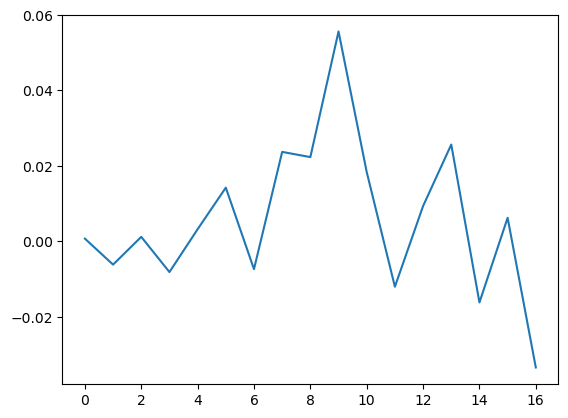

In [63]:
pd.DataFrame(history["val"])['loss'].plot()

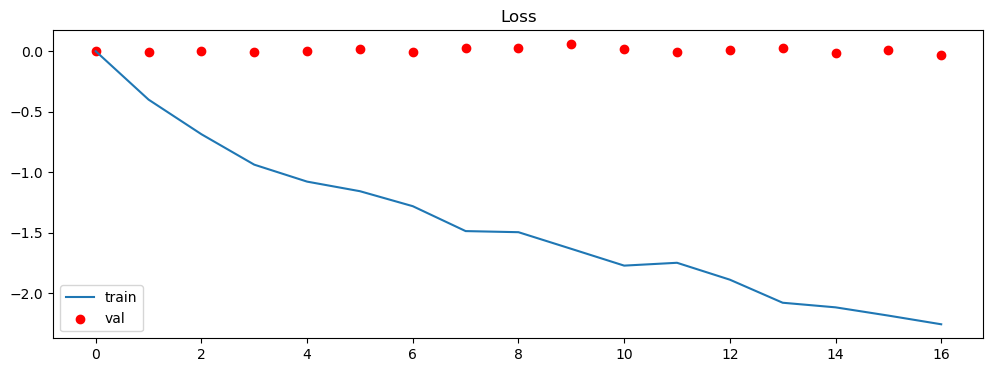

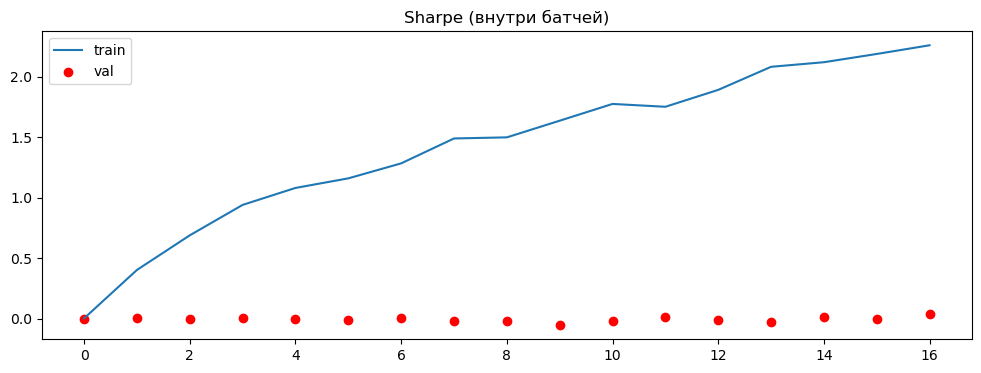

In [64]:
hist_train = pd.DataFrame(history["train"])
hist_val   = pd.DataFrame(history["val"])

plt.figure(figsize=(12,4))
plt.plot(hist_train["loss"], label="train")
plt.scatter(hist_val["loss"].index, hist_val["loss"], label="val", color='r')
plt.title("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(hist_train["sharpe"], label="train")
plt.scatter(hist_val["sharpe"].index, hist_val["sharpe"], label="val", color='r')
plt.title("Sharpe (внутри батчей)")
plt.legend()
plt.show()


## 8) Мини-бэктест на тестовом периоде

Считаем:
- серию доходностей портфеля `p_t`
- cumulative PnL (простая сумма доходностей)
- Sharpe и max drawdown на тесте  
- средний turnover (по времени)

> Это не “полный” бэктест (нет комиссий/слиппеджа), но для семинара — отлично.


X_train: (3043, 100, 792)
X_val: (600, 100, 792)
X_test: (600, 100, 792)


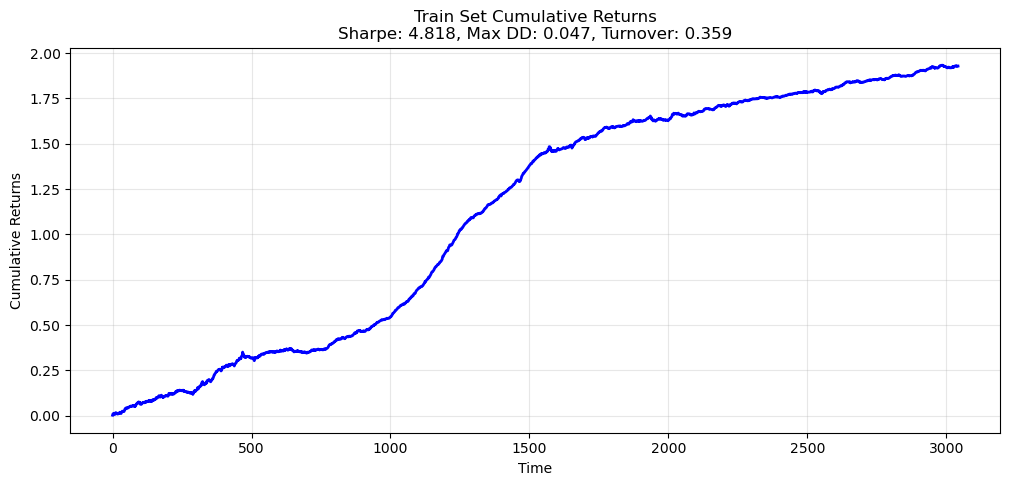

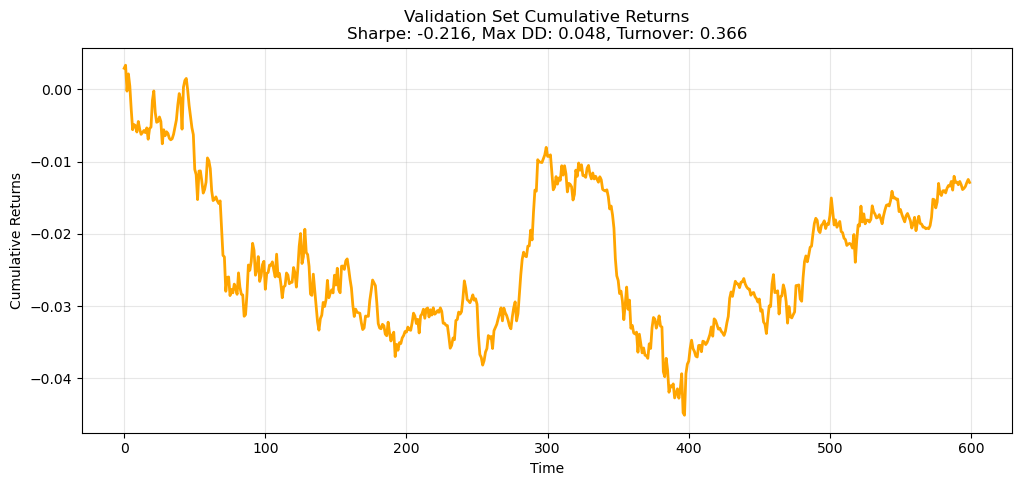

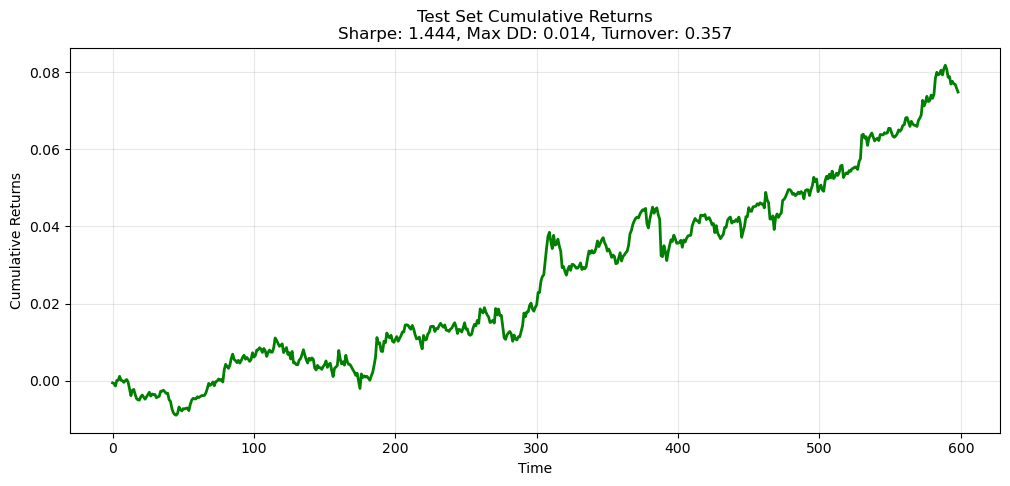

In [82]:
def predict_in_batches(model, X, device, batch_size=512):
    model.eval()
    X_tensor = torch.FloatTensor(X)
    all_predictions = []
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size].to(device)
            predictions = model(batch).cpu().numpy()
            all_predictions.append(predictions)
    
    return np.concatenate(all_predictions, axis=0)

def normalize_weights(w_df):
    w_df = w_df.sub(w_df.mean(axis=1), axis=0)  
    w_df = w_df.div(w_df.abs().sum(axis=1), axis=0)  
    return w_df

def calculate_sharpe(returns_array, periods_per_year=252):
    returns = returns_array[~np.isnan(returns_array)]
    mean_return = returns.mean()
    std_return = returns.std() + 1e-8
    sharpe = mean_return / std_return * np.sqrt(periods_per_year)
    return sharpe

def calculate_max_drawdown(cumsum_returns):
    cumsum = cumsum_returns[~np.isnan(cumsum_returns)]
    peak = np.maximum.accumulate(cumsum)
    drawdown = peak - cumsum
    max_dd = np.max(drawdown)
    return max_dd

def calculate_turnover(weights_df):
    if len(weights_df) < 2:
        return 0.0
    weight_changes = np.abs(weights_df.values[1:] - weights_df.values[:-1]).sum(axis=1)
    mean_turnover = weight_changes.mean()
    return mean_turnover

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

raw_train = predict_in_batches(model, X_train, device, batch_size=512)
w_train = pd.DataFrame(raw_train)
w_train = normalize_weights(w_train)

train_returns = (w_train.values * y_train).sum(axis=1)
train_cumsum = np.cumsum(train_returns)
train_sharpe = calculate_sharpe(train_returns)
train_max_dd = calculate_max_drawdown(train_cumsum)
train_turnover = calculate_turnover(w_train)

plt.figure(figsize=(12, 5))
plt.plot(train_cumsum, linewidth=2, color='blue')
plt.title(f'Train Set Cumulative Returns\nSharpe: {train_sharpe:.3f}, Max DD: {train_max_dd:.3f}, Turnover: {train_turnover:.3f}')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.grid(True, alpha=0.3)
plt.show()

raw_val = predict_in_batches(model, X_val, device, batch_size=512)
w_val = pd.DataFrame(raw_val)
w_val = normalize_weights(w_val)

val_returns = (w_val.values * y_val).sum(axis=1)
val_cumsum = np.cumsum(val_returns)
val_sharpe = calculate_sharpe(val_returns)
val_max_dd = calculate_max_drawdown(val_cumsum)
val_turnover = calculate_turnover(w_val)

plt.figure(figsize=(12, 5))
plt.plot(val_cumsum, linewidth=2, color='orange')
plt.title(f'Validation Set Cumulative Returns\nSharpe: {val_sharpe:.3f}, Max DD: {val_max_dd:.3f}, Turnover: {val_turnover:.3f}')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.grid(True, alpha=0.3)
plt.show()

raw_test = predict_in_batches(model, X_test, device, batch_size=512)
w_test = pd.DataFrame(raw_test)
w_test = normalize_weights(w_test)

test_returns = (w_test.values * y_test).sum(axis=1)
test_cumsum = np.cumsum(test_returns)
test_sharpe = calculate_sharpe(test_returns)
test_max_dd = calculate_max_drawdown(test_cumsum)
test_turnover = calculate_turnover(w_test)

plt.figure(figsize=(12, 5))
plt.plot(test_cumsum, linewidth=2, color='green')
plt.title(f'Test Set Cumulative Returns\nSharpe: {test_sharpe:.3f}, Max DD: {test_max_dd:.3f}, Turnover: {test_turnover:.3f}')
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.grid(True, alpha=0.3)
plt.show()



<Axes: >

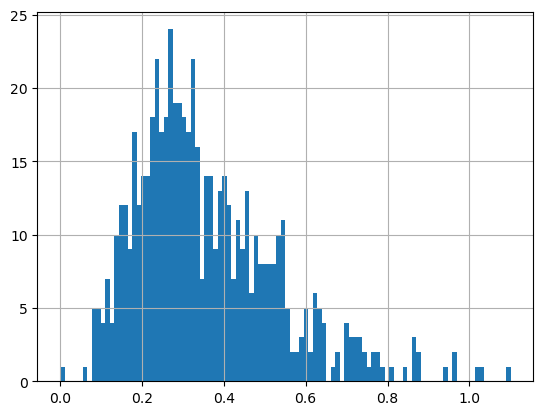

In [83]:
w_test.diff().abs().sum(axis=1).hist(bins=100)

## 10) Сохранение модели и артефактов

Сохраняем:
- веса модели (`state_dict`)
- scaler
- конфиг гиперпараметров
- итоговые метрики на тесте


In [90]:
import pickle

OUT_DIR = "LSTM_out"
os.makedirs(OUT_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(OUT_DIR, "lstm_portfolio_state_dict.pth"))

with open(os.path.join(OUT_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

config = {
    "MAX_TICKERS": MAX_TICKERS,
    "WINDOW_SIZE": WINDOW_SIZE,
    "TEST_LEN": len(X_test),
    "VAL_LEN": len(X_val),
    "model": {
        "hidden": 96,
        "num_layers": 2,
        "dropout": 0.1,
    },
    "train": {
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "grad_clip": GRAD_CLIP,
    },
    "test_metrics": {
        "sharpe_ann": float(test_sharpe),
        "max_dd": float(test_max_dd),
        "turnover": float(test_turnover)
    },
}

with open(os.path.join(OUT_DIR, "config_and_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Saved to:", os.path.abspath(OUT_DIR))

Saved to: d:\ML finance\LSTM\LSTM_out


In [88]:
torch.save(model.state_dict(), OUT_DIR + '//lstm_portfolio_state_dict.pth')
torch.save(model, OUT_DIR + '//lstm_portfolio.pth')